# Lab 2 Report:
## Iris Classification with Regression

### Name:

In [1]:
# Import neccessary packages

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import torch

In [2]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [3]:
# Image('lab2_exercise1.PNG', width = 1000)

## Prepare Data

In [4]:
from sklearn.datasets import load_iris

# iris dataset is available from scikit-learn package
iris = load_iris()

# Load the X (features) and y (targets) for training
X_train = iris['data']
y_train = iris['target']

# Load the name labels for features and targets
feature_names = iris['feature_names']
names = iris['target_names']

# Feel free to perform additional data processing here (e.g. standard scaling)

In [5]:
# Print the first 10 training samples for both features and targets

print(X_train[:10, :], y_train[:10])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]] [0 0 0 0 0 0 0 0 0 0]


In [6]:
# Print the dimensions of features and targets

print(X_train.shape, y_train.shape)

(150, 4) (150,)


In [7]:
# feature_names contains name for each column in X_train
# For targets, 0 -> setosa, 1 -> versicolor, 2 -> virginica

print(feature_names, names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] ['setosa' 'versicolor' 'virginica']


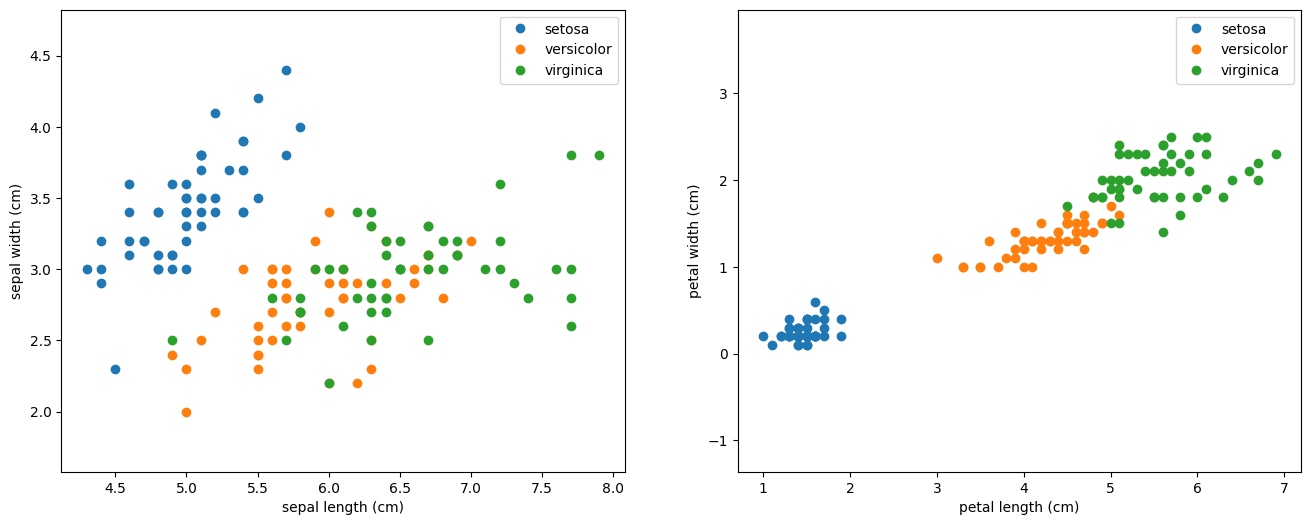

In [8]:
# We can visualize the dataset before training

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# enumerate picks up both the index (0, 1, 2) and the element ('setosa', 'versicolor', 'virginica') from "names"
# loop 1: target = 0, target_name = 'setosa'
# loop 2: target = 1, target_name = 'versicolor' etc

for target, target_name in enumerate(names):

    # Subset the rows of X_train that fall into each flower category using boolean mapping
    X_plot = X_train[y_train == target]

    # Plot the sepal length versus sepal width for the flower category
    ax1.plot(X_plot[:, 0], X_plot[:, 1], linestyle='none', marker='o', label=target_name)

# Label the plot
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.axis('equal')
ax1.legend()

# Repeat the above process but with petal length versus petal width
for target, target_name in enumerate(names):

    X_plot = X_train[y_train == target]

    ax2.plot(X_plot[:, 2], X_plot[:, 3], linestyle='none', marker='o', label=target_name)

ax2.set_xlabel(feature_names[2])
ax2.set_ylabel(feature_names[3])
ax2.axis('equal')
ax2.legend()

## Define Model

In [9]:
class irisClassification(torch.nn.Module):

    def __init__(self, input_dim, output_dim):

        super(irisClassification, self).__init__()

        # First linear layer maps input_dim # of input features to 20 neurons
        self.layer1 = torch.nn.Linear(input_dim, 20)

        # Second linear layer maps 20 neurons to output_dim # of outputs
        self.layer2 = torch.nn.Linear(20, output_dim)

    def forward(self, x):

        # Pass input through first linear layer
        out = self.layer1(x)

        # Pass result through second linear layer to get final output
        out = self.layer2(out)

        return out

## Define Hyperparameters

In [10]:
# Initialize model with 4 input features and 1 output
model = irisClassification(input_dim=4, output_dim=1)

# Step size for updating model weights during training
learning_rate = 0.01

# Number of times model sees full dataset
epochs  = 49

# We will use gradient descent for our optimizer and Mean Squared Error Loss function
loss_func = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

## Identify Tracked Values

In [11]:
# follow models performance over each epoch. Identify a metric and track it over epochs

# YOUR CODE HERE
# List to store training loss at every epoch
loss_list = []

## Train Model

In [12]:
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()

for epoch in range(epochs):

    # YOUR CODE HERE

    # Reset gradients from prev iteration
    optimizer.zero_grad()

    # Forward pass - compute model predictions
    outputs = model(X_train)

    # Compute loss between predictions and true labels
    loss = loss_func(outputs, y_train.view(-1, 1))

    # Store loss value for tracking
    loss_list.append(loss.item())

    #Backward pass - compute gradients
    loss.backward()

    # Update model weights using optimizer
    optimizer.step()

## Visualize and Evaluate Model

Text(0.5, 1.0, 'Training Loss vs Epochs')

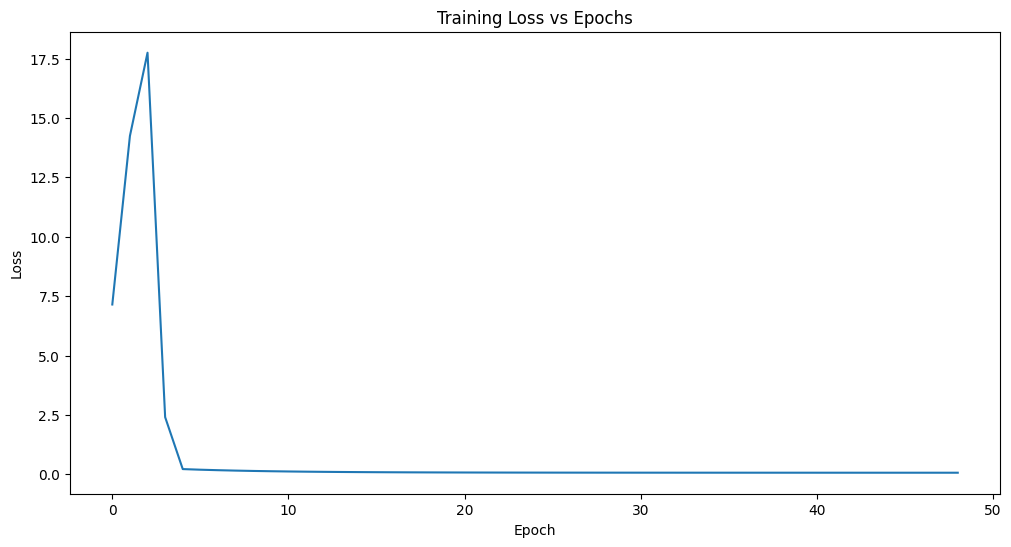

In [13]:
# Plot your training loss throughout the training
# Include proper x and y labels for the plot

plt.figure(figsize=(12, 6))

# YOUR CODE HERE
# Plot loss values stored over training
plt.plot(loss_list)

# X axis as epoch number and y axis as loss value
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")

In [14]:
# Confirm that your model's training accuracy is >90%

with torch.no_grad():

    # Compare your model predictions with targets (y_train) to compute the training accuracy

    # Get model predictions for training inputs
    predictions = model(X_train)

    # Round predictions to nearest integer
    predicted_classes = torch.round(predictions)

    # Count number of correct predictions
    correct = (predicted_classes.view(-1) == y_train).sum().item()

    # Compute accuracy as a fraction of correct predictions
    accuracy = correct / len(y_train)

    # Print
    print("Training Accuracy:", round(accuracy, 2))

# Training accuracy = (# of correct predictions) / (total # of training samples)
# You can round the model predictions to integer (e.g. 0.34 -> 0, 1.78 -> 2)

# YOUR CODE HERE

Training Accuracy: 0.95
